1. Correlation

Correlation is a statistical measure that shows how two variables move together. It tells us

1. Direction- Do they move in the same direction (positive) or opposite (negative)?

2. Strength- How strongly they are related (weak, moderate, or strong).

The most common measure is **Pearson’s correlation coefficient** (`r`).


`r` ranges between -1 and +1.

**Types of Correlation**



**Positive Correlation (r > 0)**

- As one variable increases, the other also increases.

- Example: More study hours - Higher exam scores.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set seed for reproducibility
np.random.seed(234)

In [3]:
# Create synthetic dataset 
students= 40 
study_hours = np.random.randint(1,10,students) #  1  to 9 hours study
job_hours = np.random.randint(0, 15, students)     # 0 to 14 hours job
sleep_hours = np.random.randint(4, 9, students)    # 4 to 8 hours sleep
extracurricular = np.random.randint(0, 6, students) # 0 to 5 hrs activities

# Exam score: positively influenced by study & sleep, negatively by job & extra activities
exam_score = (40 
              + 5*study_hours        # strong positive
              + 2*sleep_hours        # mild positive
              - 3*job_hours          # strong negative
              - 1*extracurricular    # mild negative
              + np.random.randint(-5,5,students))  # noise

data = pd.DataFrame({
    'Study Hours': study_hours,
    'Job Hours': job_hours,
    'Sleep Hours': sleep_hours,
    'Extracurricular Hours': extracurricular,
    'Exam Score': exam_score
})


In [4]:
data.head()

,Study Hours,Job Hours,Sleep Hours,Extracurricular Hours,Exam Score
0,9,10,4,2,56
1,5,9,5,1,46
2,2,0,6,3,57
3,4,10,6,5,37
4,8,8,7,1,69


In [5]:
# lets compute the correlation coefficients for each data feature
# 

corr_coefficients = data.corr()
corr_coefficients

,Study Hours,Job Hours,Sleep Hours,Extracurricular Hours,Exam Score
Study Hours,1.000000,-0.136551,-0.006383,-0.114442,0.694048
Job Hours,-0.136551,1.000000,0.188992,0.209991,-0.782525
Sleep Hours,-0.006383,0.188992,1.000000,0.158029,-0.035653
Extracurricular Hours,-0.114442,0.209991,0.158029,1.000000,-0.276837
Exam Score,0.694048,-0.782525,-0.035653,-0.276837,1.000000


In [6]:
data.columns

Index(['Study Hours', 'Job Hours', 'Sleep Hours', 'Extracurricular Hours',
       'Exam Score'],
      dtype='object')

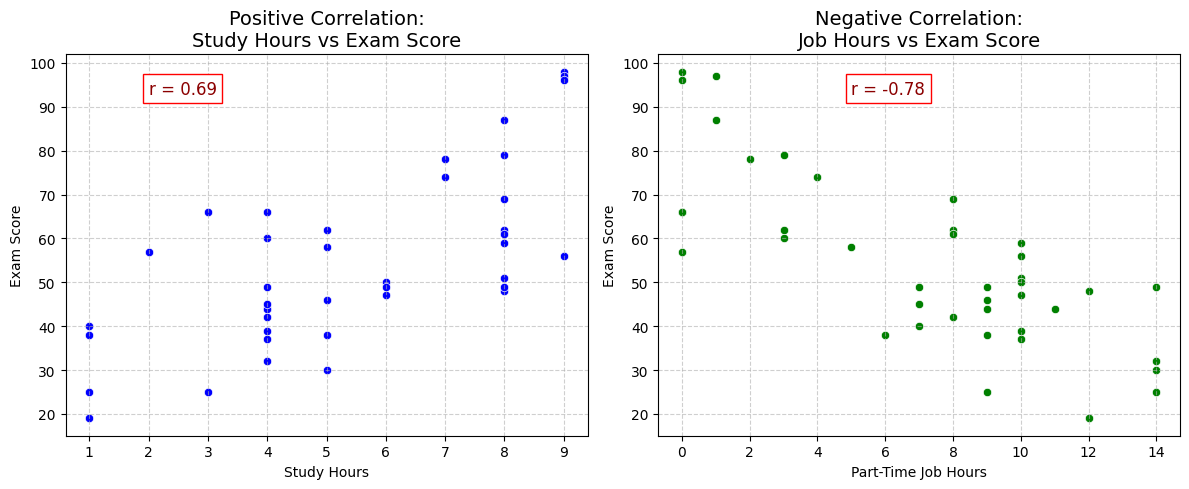

In [7]:
# Plot: Positive and Negative examples
plt.figure(figsize=(12,5))

# Positive correlation: Study vs Score
plt.subplot(1,2,1)
sns.scatterplot(x='Study Hours', y='Exam Score', data=data, color='blue')
plt.title("Positive Correlation:\nStudy Hours vs Exam Score", fontsize=14)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.text(2, max(data['Exam Score'])-5, f"r = {data.corr().loc['Study Hours','Exam Score']:.2f}",
         fontsize=12, color="darkred", bbox=dict(facecolor='white', edgecolor='red'))
plt.grid(True, linestyle="--", alpha=0.6)


# Negative correlation: Job vs Score
plt.subplot(1,2,2)
sns.scatterplot(x='Job Hours', y='Exam Score', data=data, color='green')
plt.title("Negative Correlation:\nJob Hours vs Exam Score", fontsize=14)
plt.xlabel("Part-Time Job Hours")
plt.ylabel("Exam Score")
plt.text(5, max(data['Exam Score'])-5, f"r = {data.corr().loc['Job Hours','Exam Score']:.2f}",
         fontsize=12, color="darkred", bbox=dict(facecolor='white', edgecolor='red'))

plt.grid(True, linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()

Regression 

Correlation shows whether variables move together while regression explains how much and how significantly they move together.


Regression analysis is a statistical method used to:
1. Quantify the relationship between a dependent variable(the outcome) and one or more independent variables (the predictors)

2. Predict the value of the dependent variable based on the values of the independent variables.

 Mathematically, it is about finding the best-fitting line through data points.

```python
Y = β0 +  β1x + ε

Y is dependent (outcome) variable (e.g., exam score)

X is independent (predictor) variable (e.g., study hours)

β₀ is intercept (value of Y when X = 0)

β₁ is slope or coefficient (how much Y changes when X increases by 1 unit) in simple terms it measure how much Y changes with X.

ε is error term (random noise not explained by X)

Regression doesn't just say "studying and scores are related" (that's correlation). It says "each hour of studying is associated with a 5-point increase in scores" – giving you actionable, quantified insights.



Lets put it in plain english 
if we plot students study hours vs exam scores:
we may see that as study hours increases, exam scores increases.
* Regression fits a line through the data points that best describes this upward trend.
*  The slope (β₁) tells us how strong the relationship is in actual units (not just direction like correlation).
* The slope says: "For each extra hour studied, scores increase by 5 points" (precise units)

| Component | Name | What it means | Example |
|-----------|------|---------------|---------|
| **Y** | Dependent variable | The outcome you're trying to predict | Exam score |
| **X** | Independent variable | The factor you think affects the outcome | Study hours |
| **β₀** | Intercept | Starting value of Y when X = 0 | Your baseline score with zero study |
| **β₁** | Slope (coefficient) | How much Y changes for each 1-unit increase in X | "Each hour of study increases score by 5 points" |
| **ε** | Error term | Random variation not explained by X | Natural day-to-day fluctuations |

**Types of Regression**
1. Simple Linear Regression  - One independent variable

 - `Y = β0 ​+ β1​X + ε`

2. Multiple Linear Regression - Two or more independent variables
 - `Y =β0 ​+ β1​X1 ​+ β2​X2​ + ⋯ + ε`


**OLS (Ordinary Least Squares)**

OLS finds the best-fit line by minimizing the sum of squared errors, it is said to be The Engine Behind Regression.

It is computed as;

`Residual or error =(𝑌actual −𝑌predicted)**2`


- It ensures the line we draw is the one with the smallest total deviation from all the data points.

**Interpreting Regression Results**

| Column                  | Meaning                                                             | How to Explain                                        |
| ----------------------- | ------------------------------------------------------------------- | ----------------------------------------------------- |
| **Coefficient (β)**     | Average change in Y when X increases by 1 (holding others constant) | “Every extra study hour increases score by 5 points.” |
| **Std. Error**          | How uncertain our coefficient estimate is                           | Smaller = more precise                                |
| **t-Statistic**         | Coefficient ÷ Std. Error                                            | Large t = stronger evidence the effect is real        |
| **p-Value**             | Probability that the effect is due to chance                        | p < 0.05 = statistically significant                  |
| **Confidence Interval** | Range where the true coefficient likely lies                        | Narrow = more confidence                              |
| **R-squared**           | % of variation in Y explained by Xs                                 | Closer to 1 = better model                            |


**Simple Linear Regression (SLR)**

We want to see how study hours affect exam scores using Simple Linear Regression.

In [8]:
data.head()

,Study Hours,Job Hours,Sleep Hours,Extracurricular Hours,Exam Score
0,9,10,4,2,56
1,5,9,5,1,46
2,2,0,6,3,57
3,4,10,6,5,37
4,8,8,7,1,69


In [9]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 198.7 kB/s eta 0:00:46
   -- ------------------------------------- 0.5/9.6 MB 198.7 kB/s eta 0:00:46
   -- ------------------------------------- 0.5/9.6 MB 198.7 kB/s eta 0:00:46
   -- -

In [10]:
import statsmodels.api as sm

# Define variables for simple regression
X = data['Study Hours']
Y = data['Exam Score']

In [12]:
# Adding intercept (constant term)
X = sm.add_constant(X)

In [13]:
X.head()

,const,Study Hours
0,1.0,9
1,1.0,5
2,1.0,2
3,1.0,4
4,1.0,8


In [14]:
# fit models using OLs (ordinbary least squares)
model = sm.OLS(Y,X).fit()

In [24]:
# lets check the estimated coefficients 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam Score   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     35.32
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           6.82e-07
Time:                        15:45:47   Log-Likelihood:                -161.99
No. Observations:                  40   AIC:                             328.0
Df Residuals:                      38   BIC:                             331.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          24.6404      5.476      4.500      

In [ ]:
# lets have the regression plot using regression line and scatter plots 
plt.figure(figsize=(8))
plt.scatter(data['Study Hours'],data['Exam Score'],color='skyblue',label='Actual Scores')
plt.plot(data['Study Hours'],model.predict(X),color='red',label='Regression Line')

# Annotate
plt.title('Simple Linear Regression: Study Hours vs Exam Score',fontsize=14,weight='bold')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.text(2,max(data['Exam Score'])-5,f'Y= {model.parms[0]:.2f} + {model.params[1]:.2f}X',color='red',fontsize=12)
plt.legend()
plt.grid
